# 4. Image Convolution

## Table of Contents
1. [Libraries](#libraries)
2. [Simple Example](#simple)
3. [PyTorch Convolution](#pytorch)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Simple Convolution <a class="anchor" id="simple" ></a>

### Definition

- __I__: Image to convolve.
- __H__: filter matrix to convolve the image with.
- __J__: Result of the convolution.

The following graphics shows exemplary the mathematical operations of the convolution. The filter matrix __H__ is shifted over the input image __I__. The values 'under' the filter matrix are multiplicated with the corresponding values in __H__, summed up and writen to the result __J__. The target position is usually the position under the center of __H__.

<img src="data/convolution.png" width="70%">

In order to implement the convolution with a block filter, we need two methods. The first one will create the block filter matrix __H__ depending on the filter width/height __n__.

A block filter holds the value $\dfrac{1}{n\cdot n}$ at each position:

In [83]:
def block_filter(n):
    H = np.ones((n, n)) / (n * n) # each element in H has the value 1/(n*n)
    return H

We will test the method by creating a filter with ``n = 5``:

In [84]:
H = block_filter(5)
print(H)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


Next, we define the actual convolution operation. To prevent invalid indices at the border of the image, we introduce the padding __p__.

In [85]:
def apply_filter(I, H):
    h, w = I.shape                         # image dimensions (height, width)
    n = H.shape[0]                         # filter size
    p = n // 2                             # padding size
    J = np.zeros_like(I)                   # output image, initialized with zeros

    for x in range(p, h-p):
        for y in range(p, w-p):
            J[x, y] = np.sum(I[x-p:x+n-p, y-p:y+n-p] * H)
    return J

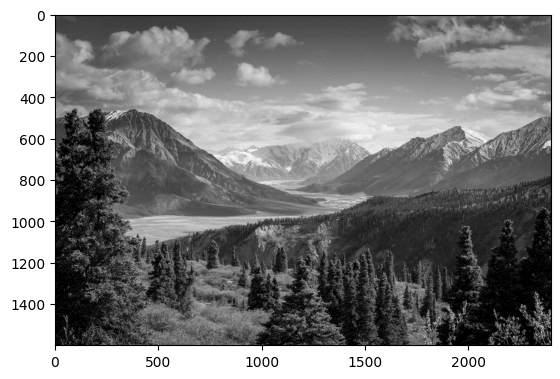

In [86]:
image = Image.open('/content/drive/MyDrive/Colab Notebooks/MIAA/Vision computacional/Practica 2/mountains.jpg')
image = image.convert('1') # convert image to black and white

image = np.array(image)

# image = np.zeros((200, 200), dtype=np.float)
# for x in range(200):
#     for y in range(200):
#         d = ((x-100)**2+(y-100)**2)**0.5
#         image[x, y] = d % 8 < 4

plt.imshow(image, cmap='gray',vmin=0.0, vmax=1.0)
plt.show()

In [87]:
image = image.astype(float)

Next we test our implementation and apply a block filter with size 7

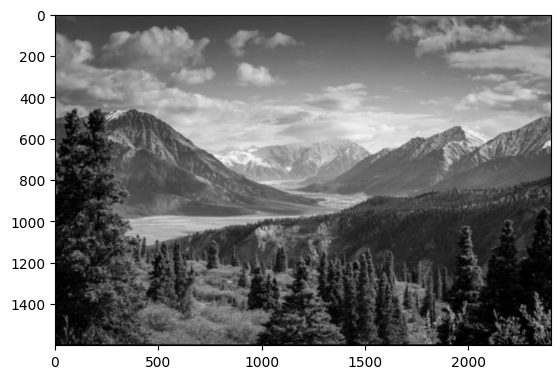

In [88]:
n = 7
H = block_filter(n)
J = apply_filter(image, H)

plt.imshow(J, cmap='gray')
plt.show()

## PyTorch Convolution <a class="anchor" id="pytorch" ></a>

In [89]:
from PIL import Image

img = Image.open('/content/drive/MyDrive/Colab Notebooks/MIAA/Vision computacional/Practica 2/mountains.jpg')
img.thumbnail((256,256), Image.Resampling.LANCZOS) # Resize to half to reduce the size of this notebook.

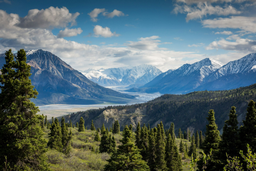

In [90]:
img

In [91]:
import torch, torchvision
from torchvision import transforms
from torch import nn

In [92]:
to_tensor = transforms.Compose([
   transforms.Grayscale(),  # Convert image to grayscale.
   transforms.ToTensor()    # Converts a PIL Image in the range [0, 255] to a torch.FloatTensor in the range [0.0, 1.0].
])

to_pil = transforms.Compose([
    transforms.ToPILImage()
])

In [93]:
input = to_tensor(img)
input.shape


torch.Size([1, 171, 256])

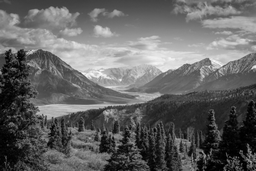

In [94]:
to_pil(input)

2D convolution over an input image:

+ `in_channels = 1`: an input is a grayscale image
+ `out_channels = 1`: an output is a grayscale image
+ `kernel_size = (3, 3)`: the kernel (filter) size is 3 x 3
+ `stride = 1`: the stride for the cross-correlation is 1
+ `padding = 1`: zero-paddings on both sides for 1 point for each dimension
+ `bias = False`: no bias parameter (for simplicity)

In [95]:
conv = nn.Conv2d(1, 1, (3, 3), stride=1, padding=1, bias=False)

In [96]:
# The code below does not work because the convolution layer requires the dimension for batch.
conv(input)

tensor([[[ 0.0116, -0.1309, -0.1272,  ..., -0.1786, -0.1851, -0.1342],
         [ 0.0108, -0.0579, -0.0529,  ..., -0.0697, -0.0755, -0.0659],
         [ 0.0063, -0.0405, -0.0381,  ..., -0.0602, -0.0746, -0.0911],
         ...,
         [-0.0085,  0.0081, -0.0201,  ..., -0.0739, -0.0376, -0.0248],
         [ 0.0100, -0.0035, -0.0245,  ..., -0.0561, -0.0492, -0.0200],
         [ 0.0068, -0.0012,  0.0461,  ...,  0.0607, -0.0408, -0.0776]]],
       grad_fn=<SqueezeBackward1>)

We need to insert a dimension for a batch at dim=0.

In [97]:
input = input.unsqueeze(0)
input.shape

torch.Size([1, 1, 171, 256])

In [98]:
output = conv(input)
output.shape

torch.Size([1, 1, 171, 256])

Setting `padding=1` in the convolution layer, we obtain an image of the same size.

In [99]:
output.shape

torch.Size([1, 1, 171, 256])

We need to remove the first dimension before converting to a PIL object.

In [100]:
output.data.squeeze(dim=0).shape

torch.Size([1, 171, 256])

Display the output from the convolution layer by converting `output` to a PIL object.

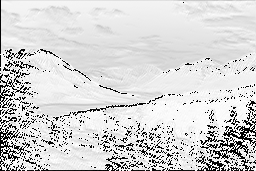

In [101]:
to_pil(output.data.squeeze(dim=0))

Clip every value in the output tensor within the range of [0, 1].

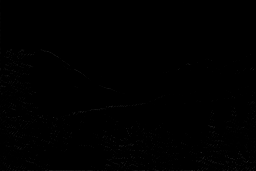

In [102]:
to_pil(torch.clamp(output, 0, 1).data.squeeze(dim=0))

In [103]:
def display(img1, img2):
    im1 = to_pil(torch.clamp(img1, 0, 1).data.squeeze(dim=0))
    im2 = to_pil(torch.clamp(img2, 0, 1).data.squeeze(dim=0))
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

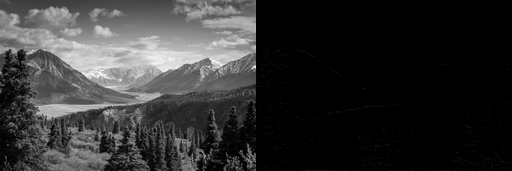

In [104]:
display(input, output)

### Identity

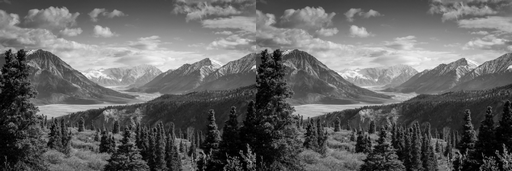

In [115]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1, 0.],
    [0., 0., 0.],
]]])

output = conv(input)
display(input, output)

### Brighten

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 1.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


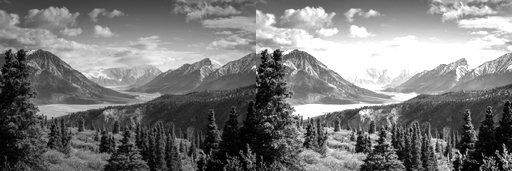

In [106]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Darken

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 0.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


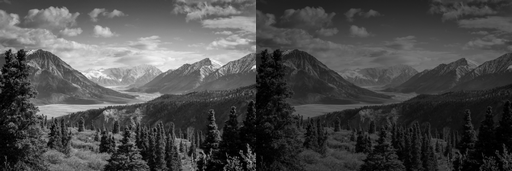

In [107]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 0.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Box blur

tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]])


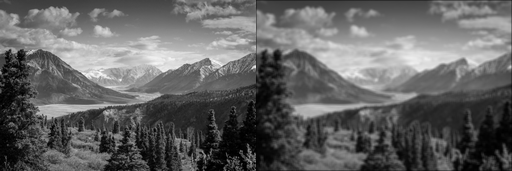

In [122]:
conv.weight.data = torch.ones((1, 1, 3,3), dtype=torch.float) / 9.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Gaussian blur

tensor([[[[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]]]])


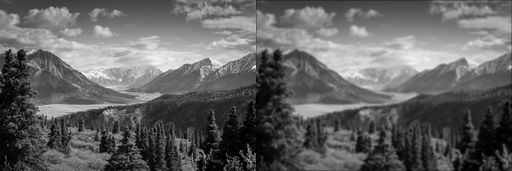

In [109]:
conv.weight.data = torch.tensor([[[
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.],
]]])/16.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Sharpen

tensor([[[[ 0., -1.,  0.],
          [-1.,  5., -1.],
          [ 0., -1.,  0.]]]])


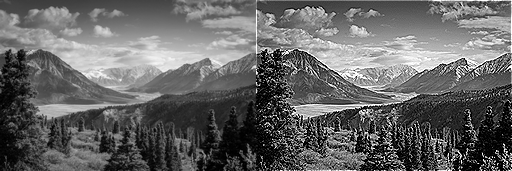

In [123]:
conv.weight.data = torch.tensor([[[
    [0., -1., 0.],
    [-1., 5., -1.],
    [0., -1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

tensor([[[[ 0., -2.,  0.],
          [-2., 10., -2.],
          [ 0., -2.,  0.]]]])


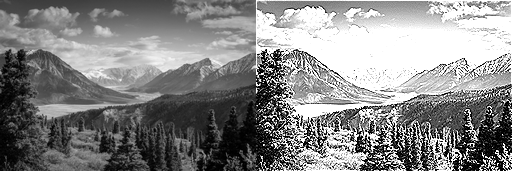

In [126]:
conv.weight.data = torch.tensor([[[
    [0., -2., 0.],
    [-2., 10., -2.],
    [0., -2., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Edge detection

tensor([[[[ 0.,  1.,  0.],
          [ 1., -4.,  1.],
          [ 0.,  1.,  0.]]]])


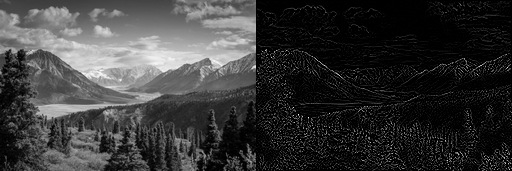

In [127]:
conv.weight.data = torch.tensor([[[
    [0., 1., 0.],
    [1., -4., 1.],
    [0., 1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

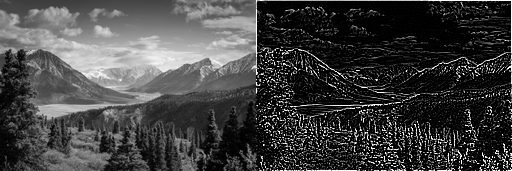

In [128]:
conv.weight.data = torch.tensor([[[
    [-1., -1., -1.],
    [-1., 8., -1.],
    [-1., -1., -1.],
]]])
output = conv(input)
display(input, output)

In [114]:
# TODO: Challenge, hard image with hard transformations

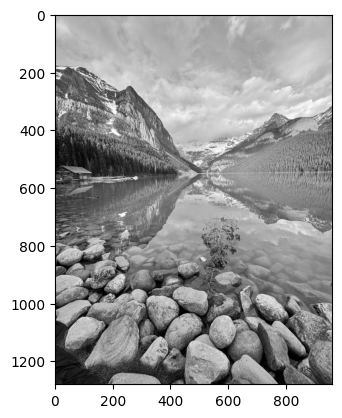

In [147]:
import numpy as np
import cv2  # Se utiliza ÚNICAMENTE para la lectura y visualización de la imagen
import matplotlib.pyplot as plt

# 2. Cargar imagen de entrada en escala de grises
# Ajusta la ruta a la imagen que vayas a utilizar
path_imagen = '/content/drive/MyDrive/Colab Notebooks/MIAA/Vision computacional/Actividad 3/lake.png'

img_gray = cv2.imread(path_imagen, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"No se encontró la imagen en {path_imagen}. Verifica la ruta.")

plt.imshow(img_gray, cmap='gray')
plt.axis('on')
plt.show()

In [148]:
# Normalizar la imagen a rango flotante [0.0, 1.0]
img_norm = img_gray.astype(np.float32) / 255.0


In [149]:
# 3. FUNCIÓN DE CONVOLUCIÓN 2D MANUAL
def convolucion2d_manual(imagen, kernel):

    h_img, w_img = imagen.shape
    h_k, w_k = kernel.shape
    pad_h, pad_w = h_k // 2, w_k // 2

    # Relleno de bordes
    padded = np.pad(imagen, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    salida = np.zeros((h_img, w_img), dtype=np.float32)

    # Deslizamiento de la ventana sobre la imagen
    for i in range(h_img):
        for j in range(w_img):
            region = padded[i:i+h_k, j:j+w_k]
            salida[i, j] = np.sum(region * kernel)

    return salida

In [150]:
# 4. DEFINICIÓN DE KERNELS DE FILTRADO
# Detector Prewitt (1ª derivada)
K_prewitt_x = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=np.float32)

K_prewitt_y = np.array([[-1, -1, -1],
                        [ 0,  0,  0],
                        [ 1,  1,  1]], dtype=np.float32)

# Detector Sobel (1ª derivada con suavizado Gaussiano)
K_sobel_x = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)

K_sobel_y = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype=np.float32)

# Detector Laplaciano (2ª derivada isotrópica)
K_laplace = np.array([[ 0,  1,  0],
                      [ 1, -4,  1],
                      [ 0,  1,  0]], dtype=np.float32)


In [151]:
# 5. APLICACIÓN DE LOS DETECTORES
# Prewitt: Magnitud del gradiente G = sqrt(Gx² + Gy²)
gx_prewitt = convolucion2d_manual(img_norm, K_prewitt_x)
gy_prewitt = convolucion2d_manual(img_norm, K_prewitt_y)
mag_prewitt = np.sqrt(gx_prewitt**2 + gy_prewitt**2)

# Sobel: Magnitud del gradiente G = sqrt(Gx² + Gy²)
gx_sobel = convolucion2d_manual(img_norm, K_sobel_x)
gy_sobel = convolucion2d_manual(img_norm, K_sobel_y)
mag_sobel = np.sqrt(gx_sobel**2 + gy_sobel**2)

# Laplaciano: Valor absoluto del resultado de la 2ª derivada
mag_laplace = np.abs(convolucion2d_manual(img_norm, K_laplace))


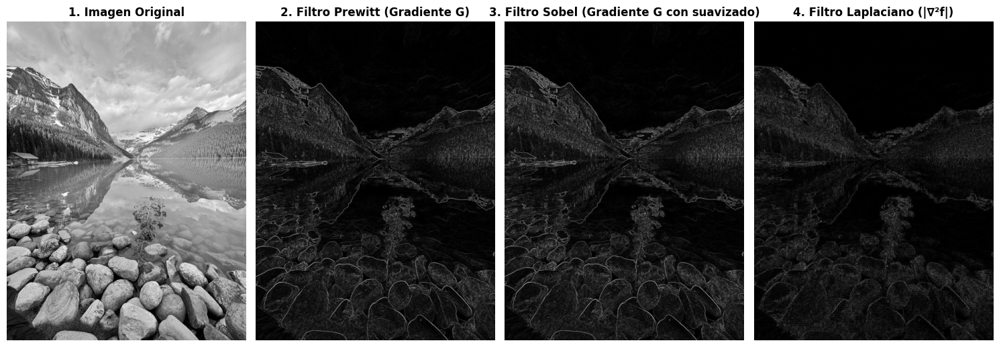

In [153]:
# 6. VISUALIZACIÓN DE RESULTADOS
plt.figure(figsize=(15, 10))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('1. Imagen Original', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mag_prewitt, cmap='gray')
plt.title('2. Filtro Prewitt (Gradiente G)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(mag_sobel, cmap='gray')
plt.title('3. Filtro Sobel (Gradiente G con suavizado)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(mag_laplace, cmap='gray')
plt.title('4. Filtro Laplaciano (|∇²f|)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

# Investigación sobre Complejidad Algorítmica y Eficiencia

## 1. Complejidad espacial y temporal de la convolución directa

Convolucionar una imagen de $M \times N$ píxeles con un kernel de $k \times k$ consiste en recorrer, para cada píxel, todo el vecindario del filtro. El costo en tiempo es

$$\mathcal{O}(M \cdot N \cdot k^{2}).$$

Con un kernel de $3 \times 3$ eso significa 9 multiplicaciones y 8 sumas por píxel. Si el kernel crece, el costo sube rápido: un $5 \times 5$ hace unas 25 operaciones por píxel, no 9.

En memoria, la salida ocupa lo mismo que la imagen, $\mathcal{O}(M \cdot N)$. El kernel casi no pesa. El límite no es el espacio, sino el tiempo: el mismo trabajo se repite en zonas que se solapan. Por eso, en imágenes grandes o con filtros amplios, la convolución directa se vuelve lenta y conviene pasarla al dominio de la frecuencia.

## Comparación entre detectores

Los tres usan un kernel de $3 \times 3$. La diferencia está en cuántas veces se recorre la imagen y en qué miden.

| Detector   | Pasadas           | Operaciones por píxel                       | Qué hace                                                                                       | Debilidad                                         |
| ---------- | ----------------- | ------------------------------------------- | ---------------------------------------------------------------------------------------------- | ------------------------------------------------- |
| Laplaciano | 1                 | 9 mult. + 8 sumas                           | Detecta cambios de intensidad en todas las direcciones con una sola matriz (segunda derivada). | Muy sensible al ruido.                            |
| Prewitt    | 2 ($G_x$ y $G_y$) | 18 mult. + 16 sumas + raíz o valor absoluto | Mide el cambio horizontal y vertical por separado, sin dar más peso al centro.                 | Bordes menos nítidos que Sobel.                   |
| Sobel      | 2 ($G_x$ y $G_y$) | 18 mult. + 16 sumas + raíz o valor absoluto | Igual que Prewitt, pero pone peso $\pm 2$ en el centro: deriva y suaviza a la vez.             | Un poco más lento de interpretar, no de calcular. |

## ¿Cuál es más eficiente?

Depende de si se mide tiempo de cálculo o calidad del borde.

**Tiempo de ejecución.** El Laplaciano es el más rápido: una sola pasada, unas $M \cdot N \cdot 9$ operaciones. Prewitt y Sobel recorren la imagen dos veces (horizontal y vertical), así que cuestan cerca del doble, más una raíz cuadrada por píxel para unir ambas direcciones.

**Calidad en la práctica.** Sobel suele ser la mejor opción. Cuesta lo mismo que Prewitt, pero da más peso al centro del kernel y suaviza un poco el ruido, así que marca menos bordes falsos. El Laplaciano es más barato, pero amplifica el ruido; por eso casi siempre se usa después de un suavizado (filtro Laplaciano de Gauss, LoG).

**Cómo bajar el costo.** Sobel y Prewitt se pueden separar en dos filtros de una dimensión. Así el costo pasa de $\mathcal{O}(M \cdot N \cdot k^{2})$ a $\mathcal{O}(M \cdot N \cdot 2k)$: con un kernel de $3 \times 3$, de 9 operaciones por pasada a 6. En imágenes muy grandes, o con kernels amplios, la FFT baja el orden a $\mathcal{O}(M \cdot N \log_{2}(M \cdot N))$.

**En resumen:** Laplaciano gana en velocidad bruta; Sobel gana en bordes útiles; la separabilidad o la FFT reducen el costo de los tres cuando la imagen crece.

**Ejercicio 2: Algoritmo de Realce y Enfoque (Unsharp Masking / High-Boost Filtering)**

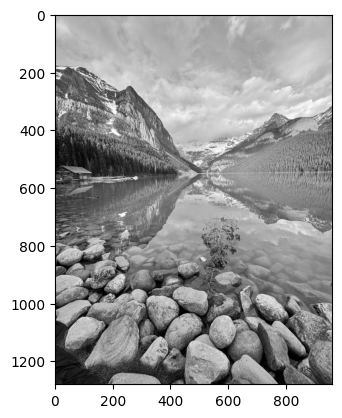

In [170]:
# 2. Cargar imagen de entrada en escala de grises
# Ajusta la ruta a la imagen que vayas a utilizar
path_imagen = '/content/drive/MyDrive/Colab Notebooks/MIAA/Vision computacional/Actividad 3/lake.png'

img_gray = cv2.imread(path_imagen, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"No se encontró la imagen en {path_imagen}. Verifica la ruta.")

plt.imshow(img_gray, cmap='gray')
plt.axis('on')
plt.show()

# Normalizar a punto flotante [0.0, 1.0]
img_norm = img_gray.astype(np.float32) / 255.0

In [171]:
# Función de Convolución 2D Manual
def convolucion2d_manual(imagen, kernel):
    h_img, w_img = imagen.shape
    h_k, w_k = kernel.shape
    pad_h, pad_w = h_k // 2, w_k // 2

    padded = np.pad(imagen, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    salida = np.zeros((h_img, w_img), dtype=np.float32)

    for i in range(h_img):
        for j in range(w_img):
            region = padded[i:i+h_k, j:j+w_k]
            salida[i, j] = np.sum(region * kernel)

    return salida

In [172]:
# 4. Extracción de Líneas / Máscara mediante Kernel Laplaciano

K_laplace_boost = np.array([[ -1, -1,  -1],
                            [-1,  8, -1],
                            [ -1, -1,  -1]], dtype=np.float32)

# Paso A: Extraer la máscara de líneas/bordes
mascara_lineas = convolucion2d_manual(img_norm, K_laplace_boost)

In [174]:
# 5. Aplicación del algoritmo con distintos factores Alfa (alpha > 1)
alphas = [1.2, 1.8, 3.5]
imagenes_realzadas = []

for alpha in alphas:
    # Paso B: Multiplicar máscara por alpha y sumar a la imagen original
    g_enhanced = img_norm + alpha * mascara_lineas

    # Paso C: Truncar/Recortar valores al rango válido [0.0, 1.0]
    g_enhanced = np.clip(g_enhanced, 0.0, 1.0)
    imagenes_realzadas.append(g_enhanced)

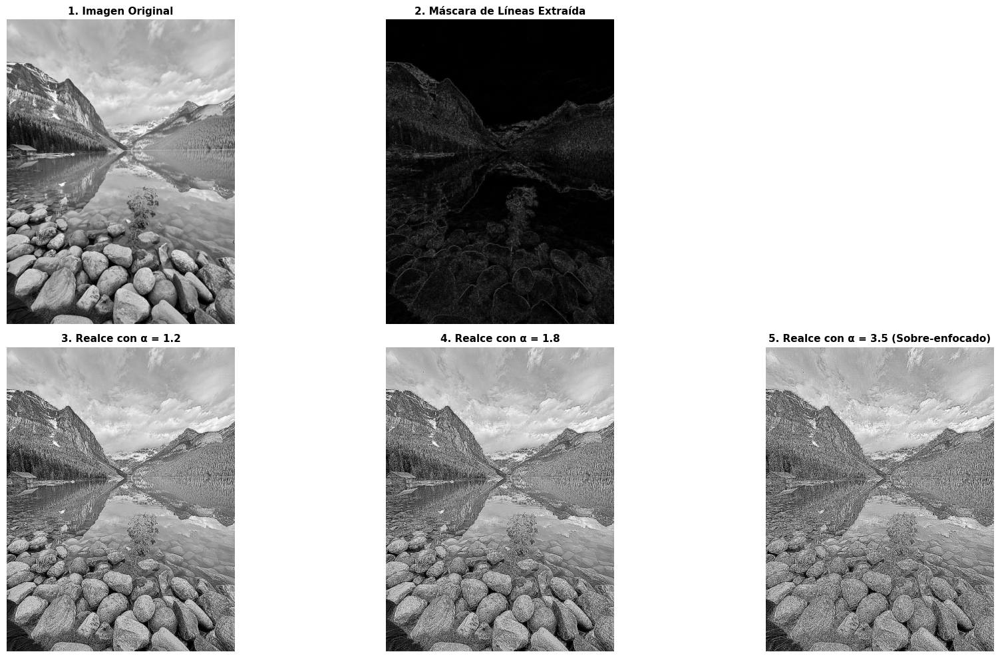

In [175]:
# 6. Visualización Comparativa
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_norm, cmap='gray')
plt.title('1. Imagen Original', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(np.abs(mascara_lineas), cmap='gray')
plt.title('2. Máscara de Líneas Extraída', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(imagenes_realzadas[0], cmap='gray')
plt.title(f'3. Realce con α = {alphas[0]}', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(imagenes_realzadas[1], cmap='gray')
plt.title(f'4. Realce con α = {alphas[1]}', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(imagenes_realzadas[2], cmap='gray')
plt.title(f'5. Realce con α = {alphas[2]} (Sobre-enfocado)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

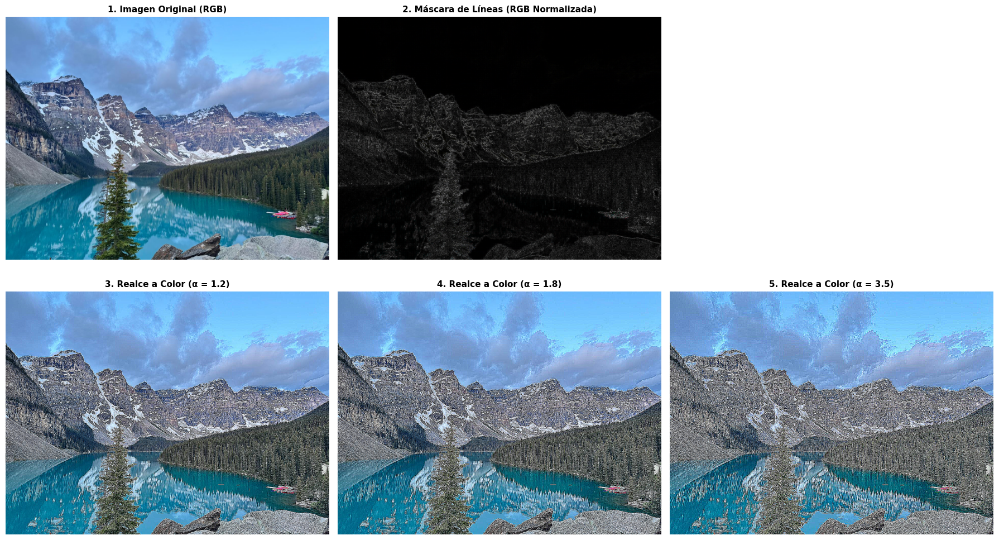

In [167]:

# Cargar imagen
path_imagen = '/content/drive/MyDrive/Colab Notebooks/MIAA/Vision computacional/Actividad 3/lake 2.png'

img_bgr = cv2.imread(path_imagen)

if img_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen en {path_imagen}.")

# Convertir de BGR (OpenCV) a RGB (Matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Normalizar a punto flotante [0.0, 1.0]
img_norm = img_rgb.astype(np.float32) / 255.0

# Función de Convolución 2D Manual en 2D (Canal por Canal)
def convolucion2d_manual(imagen_2d, kernel):
    h_img, w_img = imagen_2d.shape
    h_k, w_k = kernel.shape
    pad_h, pad_w = h_k // 2, w_k // 2

    padded = np.pad(imagen_2d, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    salida = np.zeros((h_img, w_img), dtype=np.float32)

    for i in range(h_img):
        for j in range(w_img):
            region = padded[i:i+h_k, j:j+w_k]
            salida[i, j] = np.sum(region * kernel)

    return salida

# 4. Extracción de Máscara de Líneas por Canal de Color
K_laplace_boost = np.array([[ -1, -1,  -1],
                            [-1,  8, -1],
                            [ -1, -1,  -1]], dtype=np.float32)

h, w, c = img_norm.shape
mascara_rgb = np.zeros((h, w, c), dtype=np.float32)

# Filtrado independiente para R, G, B
for canal in range(c):
    mascara_rgb[:, :, canal] = convolucion2d_manual(img_norm[:, :, canal], K_laplace_boost)

# 5. Aplicación del Realce con distintos factores Alfa (alpha > 1)
alphas = [1.2, 1.8, 3.5]
imagenes_realzadas = []

for alpha in alphas:
    # Sumar la máscara de líneas escalada a la imagen a color
    g_enhanced = img_norm + alpha * mascara_rgb

    # Restringir los valores de cada canal al rango válido [0.0, 1.0]
    g_enhanced = np.clip(g_enhanced, 0.0, 1.0)
    imagenes_realzadas.append(g_enhanced)

# 6. Preparar Máscara Normalizada para mejor visualización
mascara_vis = np.abs(mascara_rgb)
mascara_vis = (mascara_vis - mascara_vis.min()) / (mascara_vis.max() - mascara_vis.min() + 1e-8)

# 7. Visualización Comparativa
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_norm)
plt.title('1. Imagen Original (RGB)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mascara_vis)
plt.title('2. Máscara de Líneas (RGB Normalizada)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(imagenes_realzadas[0])
plt.title(f'3. Realce a Color (α = {alphas[0]})', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(imagenes_realzadas[1])
plt.title(f'4. Realce a Color (α = {alphas[1]})', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(imagenes_realzadas[2])
plt.title(f'5. Realce a Color (α = {alphas[2]})', fontsize=11, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

## Análisis de resultados

### ¿Qué pasa si sube $\alpha$?

La máscara solo marca los bordes fuertes: crestas, grietas de la roca, orilla del lago y el pino del primer plano. El agua y el cielo quedan casi negros, porque ahí hay poco detalle.

Al sumar esa máscara, $\alpha$ decide cuánto se refuerzan esos bordes. Con $\alpha = 1.2$ el cambio es leve: la roca y el pino se ven un poco más definidos y el lago conserva el tono turquesa. Con $\alpha = 1.8$ el contraste sube en las crestas y en las ramas. Con $\alpha = 3.5$ el relieve de la montaña y el contorno del pino se marcan más; el cielo y el agua siguen suaves. En esta figura el salto no es drástico: el realce se concentra donde ya había borde, no en las zonas planas.

Si $\alpha$ siguiera subiendo, esos mismos bordes (pino contra cielo, cresta contra nube) tenderían a saturarse y a formar un halo claro. En $\alpha = 3.5$ ese defecto todavía no domina la imagen.



**ACTIVIDAD PRÁCTICA 3 | EJERCICIO 3: MEJORAMIENTO MULTIETAPA PARA IMÁGENES MÉDICAS**

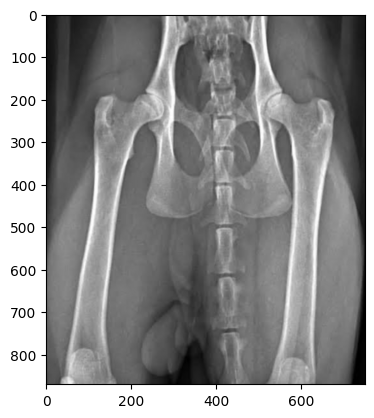

In [209]:
# Cargar imagen de entrada en escala de grises
# Ajusta la ruta a la imagen que vayas a utilizar
path_imagen = '/content/drive/MyDrive/Colab Notebooks/MIAA/Vision computacional/Actividad 3/Pelvis.png'

img_gray = cv2.imread(path_imagen, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"No se encontró la imagen en {path_imagen}. Verifica la ruta.")

plt.imshow(img_gray, cmap='gray')
plt.axis('on')
plt.show()

# Normalizar a punto flotante [0.0, 1.0]
img_norm = img_gray.astype(np.float32) / 255.0

In [210]:
# Etapa (a): Imagen original f(x,y)
img_a = img_norm.copy()

# Etapa (b): Laplaciano con centro positivo (para restar)
K_laplace = np.array([[1, 1, 1],
                      [1, -8, 1],
                      [1, 1, 1]], dtype=np.float32)
img_b = cv2.filter2D(img_norm, -1, K_laplace)

# Etapa (c): Imagen enfocada con Laplaciano g1 = f - Laplaciano
img_c = img_norm - img_b
img_c = np.clip(img_c, 0.0, 1.0)

# Etapa (d): Gradiente de Sobel M(x,y) = sqrt(Gx² + Gy²)
gx = cv2.Sobel(img_norm, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(img_norm, cv2.CV_32F, 0, 1, ksize=3)
img_d = np.sqrt(gx**2 + gy**2)
img_d = (img_d - img_d.min()) / (img_d.max() - img_d.min() + 1e-8)


# Etapa (e): Gradiente de Sobel suavizado con filtro promedio de 5x5
K_box5x5 = np.ones((5, 5), dtype=np.float32) / 25.0
img_e = cv2.filter2D(img_d, -1, K_box5x5)

# Etapa (f): Imagen máscara producto = (c) * (e)
img_f = img_c * img_e

# Etapa (g): Suma con factor de ganancia k (ejemplo k = 1.5 o 2.0)
k = 1.5  # Si pones k = 1.0, es exactamente la fórmula estándar f + img_f
img_g = img_norm + k * img_f
img_g = np.clip(img_g, 0.0, 1.0)

# Etapa (h): Corrección Gamma (gamma = 0.5) para expandir rango dinámico en oscuros
gamma = 2.5
img_h = np.power(img_g, gamma)
img_h = np.clip(img_h, 0.0, 1.0)

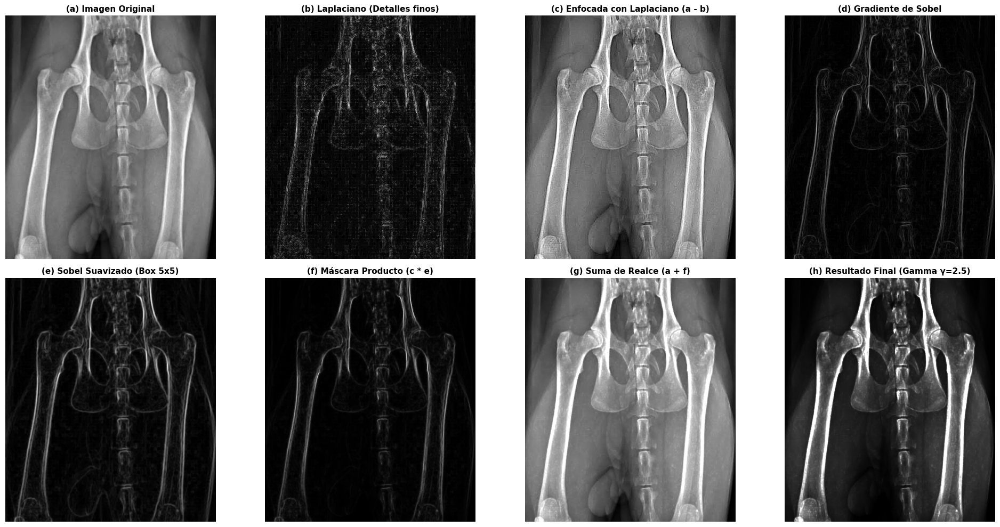

In [211]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(img_a, cmap='gray')
plt.title('(a) Imagen Original', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(np.abs(img_b), cmap='gray', vmin=0, vmax=0.3)
plt.title('(b) Laplaciano (Detalles finos)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(img_c, cmap='gray')
plt.title('(c) Enfocada con Laplaciano (a - b)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(img_d, cmap='gray')
plt.title('(d) Gradiente de Sobel', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(img_e, cmap='gray')
plt.title('(e) Sobel Suavizado (Box 5x5)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(img_f, cmap='gray')
plt.title('(f) Máscara Producto (c * e)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(img_g, cmap='gray')
plt.title('(g) Suma de Realce (a + f)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(img_h, cmap='gray')
plt.title('(h) Resultado Final (Gamma γ=2.5)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

El método que se muestra en el libro de González y Woods mejoró el escaneo óseo de cuerpo completo en cuatro pasos. La imagen de partida tenía poco contraste y ruido de fondo.

1. **Laplaciano (8 vecinos, centro $-8$).** Marcó los cambios finos de intensidad en todas las direcciones: horizontal, vertical y diagonal.
2. **Sobel suavizado ($5 \times 5$).** Localizó el contorno del esqueleto. El suavizado posterior convirtió ese borde en una máscara continua.
3. **Producto de las dos máscaras.** Se multiplicaron punto a punto. Así el realce se quedó en el hueso y se apagó el grano del fondo, donde no hay estructura.
4. **Suma y gamma ($\gamma = 2.5$).** Esa máscara se sumó a la imagen original. La corrección gamma aclaró los tonos oscuros y medios, y dejó ver mejor la pelvis.

En conjunto, el algoritmo no realza toda la imagen: solo refuerza el borde óseo y luego abre el contraste donde esos detalles estaban apagados.